# Chapter 5 — Comparing Models

Notes on Chapter 5 of *Bayesian Analysis with Python* (3rd edition).

## Set-up

### Imports

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from scipy import stats
import seaborn as sns

import const

### Defaults

In [2]:
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(const.RANDOM_SEED)

### Constants

In [3]:
# Data file paths and other hardcoded values go here

## Load data

`dummy.csv` is two whitespace-separated columns with no header: a predictor `x` and a response `y`.

In [4]:
dummy = pd.read_csv(const.DUMMY_DATA_PATH, sep=r"\s+", header=None, names=["x", "y"])
dummy.head()

,x,y
0,-1.081,9.357
1,-0.888,8.322
2,-0.623,8.745
3,-0.480,7.346
4,-0.505,7.028


## Posterior predictive checks

### Visualise the data

[Text(0.5, 1.0, 'Dummy data (standardised)'),
 Text(0.5, 0, 'x (standardised)'),
 Text(0, 0.5, 'y (standardised)')]

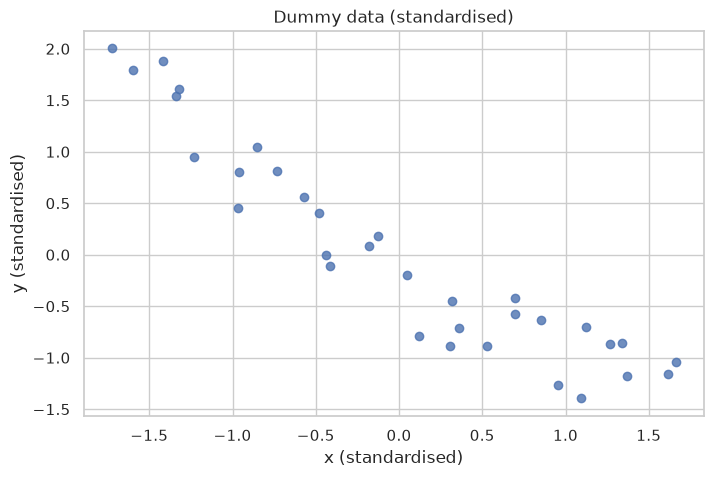

In [5]:
x = dummy["x"].to_numpy()
y = dummy["y"].to_numpy()
x_c = (x - x.mean()) / x.std()
y_c = (y - y.mean()) / y.std()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(x_c, y_c, alpha=0.8)
ax.set(title="Dummy data (standardised)", xlabel="x (standardised)", ylabel="y (standardised)")

### Fit a linear and a quadratic model

Following the book, we standardise the response $y$ and each polynomial feature $x^i$ (zero mean, unit variance) before fitting, so the coefficients live on a common scale.
The models share the same likelihood and priors and differ only in the polynomial order $d$ of the mean:

$$
\begin{align*}
\alpha &\sim \mathcal{N}(0, 1) \\
\beta_i &\sim \mathcal{N}(0, 1) \\
\sigma &\sim \text{Exponential}(\text{scale}=5) \\
\mu &= \alpha + \sum_{i=1}^{d} \beta_i \, \tilde{x}_i \\
y &\sim \mathcal{N}(\mu, \sigma)
\end{align*}
$$

where $\tilde{x}_i$ is the standardised $x^i$, with $d = 1$ for the linear model and $d = 2$ for the quadratic.

In [6]:
def fit_polynomial(order):
    x = dummy["x"].to_numpy()
    y = dummy["y"].to_numpy()

    # standardise each polynomial feature and the response
    x_p = np.vstack([x**i for i in range(1, order + 1)])
    x_c = (x_p - x_p.mean(axis=1, keepdims=True)) / x_p.std(axis=1, keepdims=True)
    y_c = (y - y.mean()) / y.std()

    coords = {"poly": range(order), "obs": range(len(y))}
    with pm.Model(coords=coords) as model:
        # data
        X = pm.Data("X", x_c, dims=("poly", "obs"))

        # priors
        alpha = pm.Normal("alpha", mu=0, sigma=1)
        beta = pm.Normal("beta", mu=0, sigma=1, dims="poly")
        sigma = pm.Exponential("sigma", scale=5)

        # likelihood
        mu = alpha + pm.math.dot(beta, X)
        y_pred = pm.Normal("y", mu=mu, sigma=sigma, observed=y_c, dims="obs")

        # sample
        idata = pm.sample(draws=1000, chains=4, random_seed=const.RANDOM_SEED)
        pm.sample_posterior_predictive(idata, extend_inferencedata=True, random_seed=const.RANDOM_SEED)

    return idata

In [7]:
idata_lin = fit_polynomial(1)
idata_quad = fit_polynomial(2)
models = {"linear": idata_lin, "quadratic": idata_quad}

NUTS[nutpie]: [alpha, beta, sigma]


Output()

Sampling: [y]


Output()

NUTS[nutpie]: [alpha, beta, sigma]


Output()

Sampling: [y]


Output()

Quick convergence check before interpreting anything.

In [8]:
pd.DataFrame(
    [
        {
            "model": name,
            "max_r_hat": az.summary(idata, var_names=["alpha", "beta", "sigma"])["r_hat"].max(),
            "min_ess_bulk": az.summary(idata, var_names=["alpha", "beta", "sigma"])["ess_bulk"].min(),
            "divergences": int(idata.sample_stats["diverging"].sum()),
        }
        for name, idata in models.items()
    ]
)

,model,max_r_hat,min_ess_bulk,divergences
0,linear,1.00,4034,0
1,quadratic,1.00,1167,0


### Posterior predictive densities (`plot_ppc`)

For each model, overlay a sample of posterior predictive densities (thin grey), their mean (dashed), and the observed density (black) — all computed with arviz's KDE (`az.kde`).
The linear model's predictive mean is a flat plateau that can't match the peaked observed density; the quadratic model's mean tracks it closely.

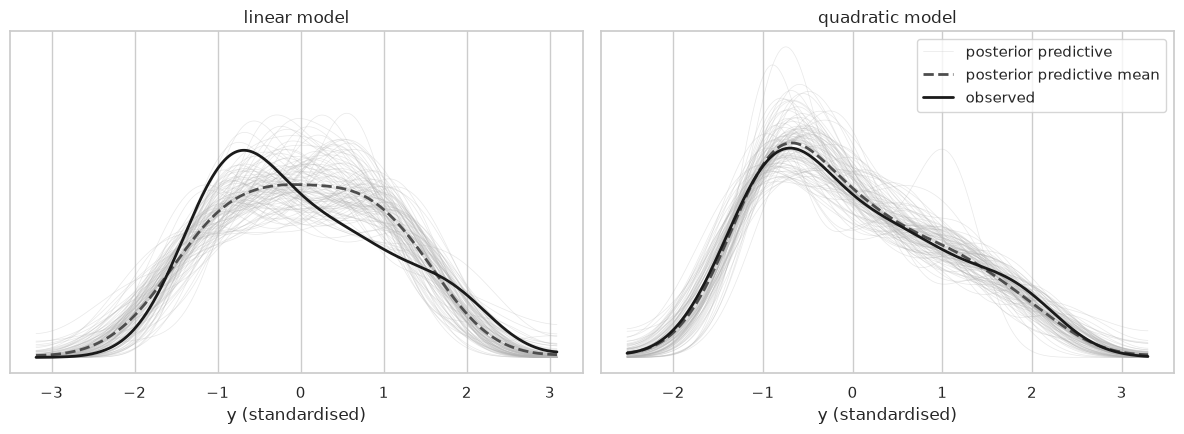

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, (name, idata) in zip(axes, models.items()):
    obs = idata.observed_data["y"].to_numpy()
    pp = idata.posterior_predictive["y"].to_numpy().reshape(-1, len(obs))

    # evaluate every KDE on a shared grid so the densities can be averaged directly
    lims = (pp.min(), pp.max())
    densities = []
    for i, draw in enumerate(rng.permutation(pp)[:100]):
        grid, density, _ = az.kde(draw, custom_lims=lims)
        ax.plot(grid, density, color="0.7", lw=0.5, alpha=0.3,
                label="posterior predictive" if i == 0 else None)
        densities.append(density)
    ax.plot(grid, np.mean(densities, axis=0), "--", color="0.3", lw=2,
            label="posterior predictive mean")

    grid, density, _ = az.kde(obs, custom_lims=lims)
    ax.plot(grid, density, "k", lw=2, label="observed")
    ax.set(title=f"{name} model", xlabel="y (standardised)", yticks=[])
axes[1].legend()
fig.tight_layout()

### Test-statistic checks with `plot_bpv`

For a chosen statistic $T$ (say the mean or IQR), compute $T$ on each posterior predictive dataset to build up its distribution, then see where the observed value $T(y)$ falls within it.
The **Bayesian p-value** is that position in the CDF, $\text{bpv} = P(T(y^{rep}) \le T(y))$: near $0.5$ means the observed value is typical of what the model predicts, near $0$ or $1$ means it isn't.
Each row below is one statistic, with both models overlaid and their bpv in the legend.

The **mean** is uninformative here: both intercepts absorb it, so both bpv values sit near $0.5$.
The **IQR** shows both models slightly underestimate the spread of $y$ (bpv $> 0.5$, so the replicated IQR usually falls below the observed one).
The quadratic underestimates it a little more — its smaller residual $\sigma$ gives tighter replicated data than the linear model's inflated $\sigma$ — a reminder that aggregate test statistics can miss the structure the full density plot reveals.

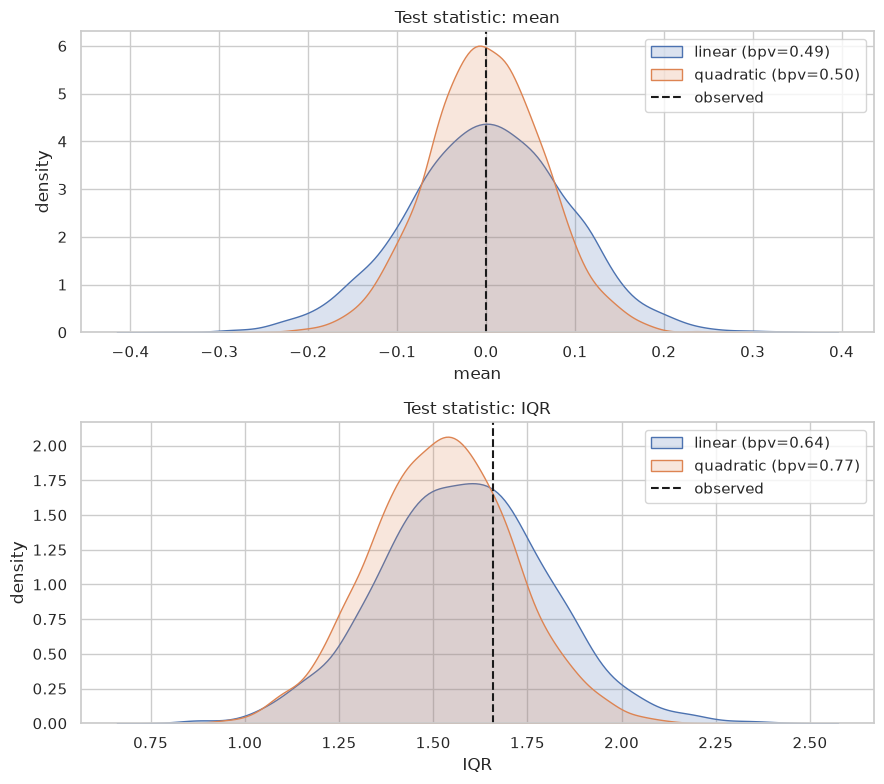

In [10]:
stat_funcs = {"mean": np.mean, "IQR": stats.iqr}
y_obs = idata_lin.observed_data["y"].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(9, 8))
for ax, (stat_name, func) in zip(axes, stat_funcs.items()):
    obs = func(y_obs)
    for i, (name, idata) in enumerate(models.items()):
        pp = idata.posterior_predictive["y"].to_numpy().reshape(-1, len(y_obs))
        rep = func(pp, axis=1)
        bpv = np.mean(rep <= obs)
        sns.kdeplot(rep, ax=ax, color=f"C{i}", fill=True, alpha=0.2,
                    label=f"{name} (bpv={bpv:.2f})")
    ax.axvline(obs, color="k", ls="--", label="observed")
    ax.set(title=f"Test statistic: {stat_name}", xlabel=stat_name, ylabel="density")
    ax.legend()
fig.tight_layout()